
![image.png](img/c2.jpg)

참조 : https://heasarc.gsfc.nasa.gov/docs/rosat/gallery/snr_cygloop.html



목표치, 실제 사진을 참고해서   
주변부를 적당하게 날리기,    

성운을 둘러싼 약간의 점층만 만들기



In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import sys

In [5]:
gray = cv.imread('img/cygnusloop.tif', cv.IMREAD_GRAYSCALE)

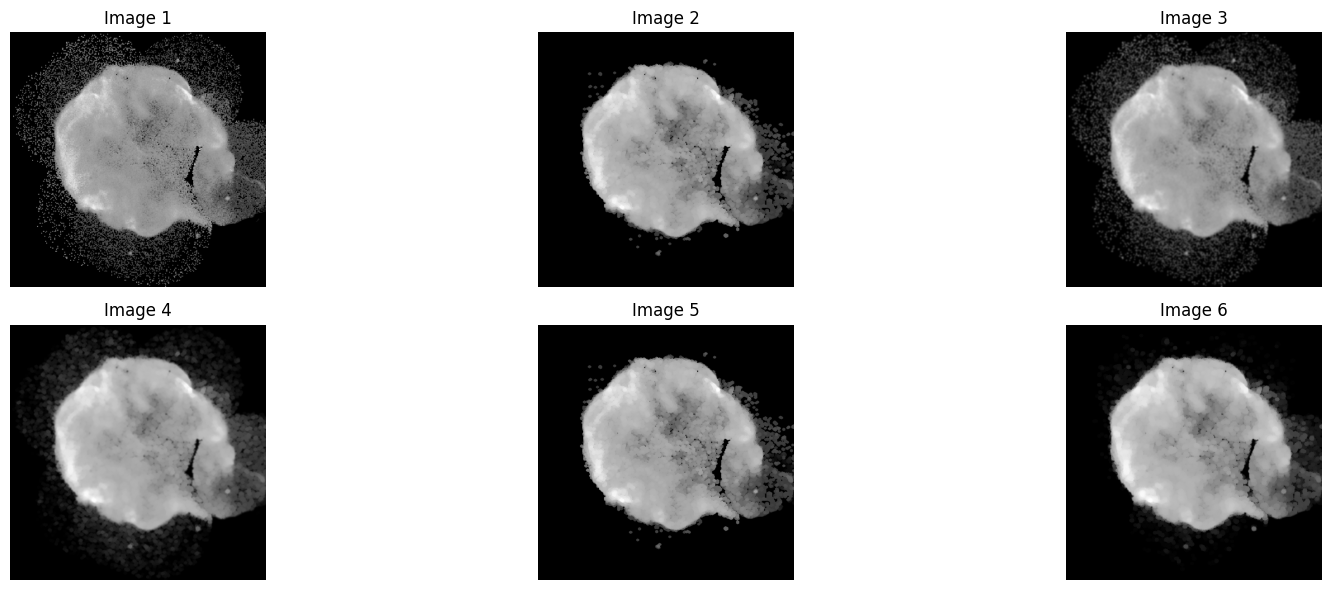

In [ ]:
#  Morphological Smoothing

# kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7))
ms = cv.morphologyEx(gray, cv.MORPH_OPEN, kernel)

# Smoothing Filter 
# gaussian_smoothing = cv.GaussianBlur(gray, (5, 5), 0)
gs = cv.GaussianBlur(gray, (7, 7), 0)



msgs = cv.morphologyEx(gs, cv.MORPH_OPEN, kernel)
# 별로 적당하진 않음 

gsms = cv.morphologyEx(ms, cv.MORPH_OPEN, kernel)


# 가우시안으로 주변부를 블러처리해서 노이즈를 성운의 확장처럼 만들고 
# 모폴로지 스무딩으로 번진 범위를 줄이는 방향으로 생성 

gst_f = cv.GaussianBlur(gray, (3, 3), 0)
kernel_f = cv.getStructuringElement(cv.MORPH_ELLIPSE, (9, 9))
ms_f = cv.morphologyEx(gst_f, cv.MORPH_OPEN, kernel_f)


images = [gray, ms, gs, msgs, gsms, ms_f]

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.title(f'Image {i+1}')
    plt.imshow(images[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

실제 cygnusloop  의 사진을 참고하니   
실제로 큰 성운을 위시하여 주변부에 별이 있는 상태  

6번 : 
가우시안으로 주변부를 블러처리해서 노이즈를 성운의 확장처럼 만들고   
모폴로지 스무딩으로 번진 범위를 줄이는 방향으로 생성 

▪ Morphological Smoothing

모양과 구조를 확실하게 구분하려는 필터링 작업을 수행한다.   
조금만 값을 키워도 영상에 있는 픽셀이 많이 사라진다.   
그 만큼 밝기나 픽셀 간 간격이 외곽은 분산되어 있다는 것을 말해준다. 

▪ Smoothing Filter

가장 기억나는 가우시안을 적용하였다.   
박스 필터보다 점진적인 확산이 밝기가 변하는 구역을 더 잘 부드러게 만든다. 

